# IPR


In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import numpy as np
import matplotlib.pyplot as plt

class IPR:
    """
    Calculates and plots the Inflow Performance Relationship (IPR) using the 
    Composite Darcy-Vogel model for undersaturated and saturated oil reservoirs.
    """

    def __init__(self, Pr, Pb, q_test, Pwf_test):
        """
        Initializes the IPR model and locks in the well's Productivity Index (J).

        Args:
            Pr (float): Static Reservoir Pressure in psia.
            Pb (float): Bubble Point Pressure in psia.
            q_test (float): Tested liquid flow rate in STB/day.
            Pwf_test (float): Tested Bottom-Hole Flowing Pressure in psia.
        """
        self.Pr = Pr
        self.Pb = Pb
        self.q_test = q_test
        self.Pwf_test = Pwf_test
        
        # 1. Lock in the Productivity Index (J) based on test data
        self.J = self._calculate_pi()
        
        # 2. Calculate flow rate exactly at the bubble point (q_bp)
        self.q_bp = self.J * (self.Pr - self.Pb)
        
        # 3. Calculate Absolute Open Flow (q_max)
        self.q_max = self._calculate_aof()

    def _calculate_pi(self):
        """
        Calculates the Productivity Index (J) using the initial test point.
        Internal method called only during initialization.

        Returns:
            float: Productivity Index in STB/day/psi.
        """
        if self.Pwf_test >= self.Pb:
            # Darcy linear regime
            return self.q_test / (self.Pr - self.Pwf_test)
        else:
            # Vogel curve regime (Note: Denominator is Pb, not Pr)
            vogel_term = 1.0 - 0.2 * (self.Pwf_test / self.Pb) - 0.8 * (self.Pwf_test / self.Pb)**2
            return self.q_test / ((self.Pr - self.Pb) + (self.Pb / 1.8) * vogel_term)

    def _calculate_aof(self):
        """
        Calculates Absolute Open Flow (AOF) where Pwf equals zero.

        Returns:
            float: Maximum flow rate (q_max) in STB/day.
        """
        return self.q_bp + (self.J * self.Pb) / 1.8

    def calculate_q(self, Pwf):
        """
        Calculates the expected flow rate (q) for a given Bottom-Hole Pressure.

        Args:
            Pwf (float): Target Bottom-Hole Flowing Pressure in psia.

        Returns:
            float: Calculated flow rate in STB/day.
        """
        if Pwf >= self.Pb:
            # Darcy linear regime
            return self.J * (self.Pr - Pwf)
        else:
            # Vogel curve regime
            vogel_term = 1.0 - 0.2 * (Pwf / self.Pb) - 0.8 * (Pwf / self.Pb)**2
            return self.q_bp + (self.J * self.Pb / 1.8) * vogel_term

    def calculate_Pwf(self, q):
        """
        Calculates the required Bottom-Hole Pressure (Pwf) for a target flow rate.

        Args:
            q (float): Target liquid flow rate in STB/day.

        Returns:
            float: Calculated Bottom-Hole Flowing Pressure in psia.
        """
        # Bound the query so we don't try to calculate past Absolute Open Flow
        q_target = min(q, self.q_max)

        if q_target <= self.q_bp:
            # Darcy linear regime
            return self.Pr - (q_target / self.J)
        else:
            # Vogel quadratic inversion
            C = (1.8 / self.Pb) * ((q_target / self.J) - self.Pr + self.Pb)
            radicand = max(0.0, 3.24 - 3.2 * C)
            Pwf = self.Pb * (np.sqrt(radicand) - 0.2) / 1.6
            return max(0.0, Pwf)

    def plot_ipr(self, points=50):
        """
        Generates a plot of the IPR curve from zero flow up to Absolute Open Flow.

        Args:
            points (int): Number of calculation nodes to generate a smooth curve.
        """
        Q = np.linspace(0, self.q_max, points)
        Pwf_points = [self.calculate_Pwf(q) for q in Q]
        
        plt.figure(figsize=(10, 6))
        plt.plot(Q, Pwf_points, label='Calculated IPR Curve', color='crimson', linewidth=2)
        plt.scatter(self.q_test, self.Pwf_test, color='black', zorder=5, label='Well Test Data Point')
        plt.scatter(self.q_bp, self.Pb, color='blue', marker='x', s=100, zorder=5, label='Bubble Point Transition')
        
        plt.title('Inflow Performance Relationship (IPR)', fontweight='bold')
        plt.xlabel('Liquid Flow Rate, q (STB/day)')
        plt.ylabel('Bottom-Hole Flowing Pressure, Pwf (psia)')
        plt.ylim(bottom=0)
        plt.xlim(left=0)
        
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

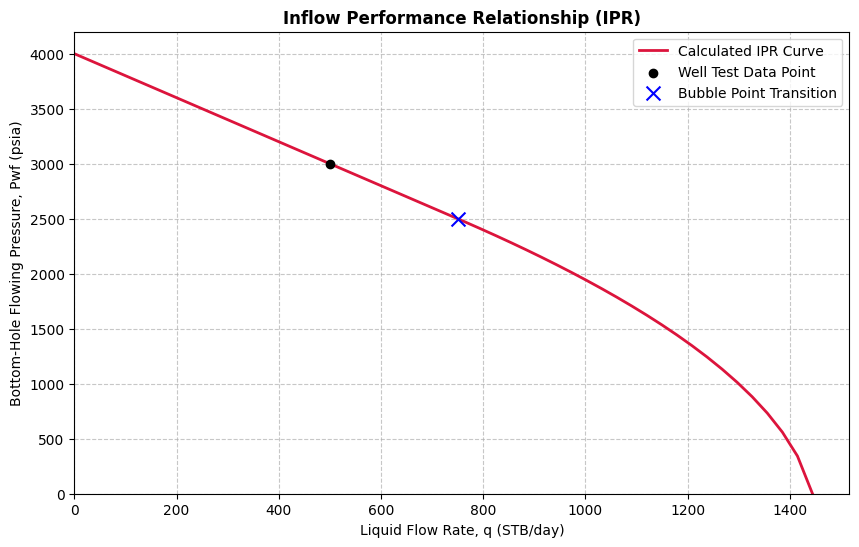

In [ ]:
IPR_model = IPR(Pr=4000, Pb=2500, q_test=500, Pwf_test=3000)
IPR_model.plot_ipr()

In [13]:
class fetkovich_ipr:
    """
    Calculates and plots the Inflow Performance Relationship (IPR) using 
    Fetkovich for reservoirs for non-Darcy flow.
    """
    def __init__(self, Pr, Pb, q_test, Pwf_test, q_test2, Pwf_test2):
        self.Pr = Pr
        self.Pb = Pb  # Included for API compatibility with other models
        self.q_test = q_test
        self.Pwf_test = Pwf_test
        self.q_test2 = q_test2
        self.Pwf_test2 = Pwf_test2
        
        self.n = self._calculate_exponent()
        self.C = self._calculate_constant()
        self.q_max = self._calculate_aof()
        self.J = (self.q_test * 2 * self.Pb) / ((self.Pr**2 - self.Pwf_test**2)**self.n)

    def _calculate_exponent(self):
        n = (np.log(self.q_test) - np.log(self.q_test2))/(np.log(self.Pr**2 - self.Pwf_test**2) - (np.log(self.Pr**2 - self.Pwf_test2**2) ))
        if n < 0.5 or n > 1.0:
            print(
            f"Calculated Fetkovich exponent (n = {n:.2f}) falls outside the physical "
            f"bounds of 0.5 to 1.0. This indicates un-stabilized well tests, changing skin, "
            f"or bad gauge data. The value will be clipped to the nearest physical bound."
            )
        return np.clip(n, 0.5, 1.0)

    def _calculate_constant(self):
        return self.q_test/(self.Pr**2 - self.Pwf_test**2) **self.n

    def _calculate_aof(self):
        return self.C * self.Pr**(2*self.n)
    
    def calculate_q(self, Pwf):
        return self.C * (self.Pr**2 - Pwf**2)**self.n

    def calculate_Pwf(self, q):
        if q >= self.q_max:
            return 0.0
        core = self.Pr**2 - (q/self.C)**(1/self.n)
        return np.sqrt(max(0.0, core))

    def plot_ipr(self, points=50):
        Q = np.linspace(0, self.q_max, points)
        Pwf_points = [self.calculate_Pwf(q) for q in Q]
        
        plt.figure(figsize=(10, 6))
        plt.plot(Q, Pwf_points, label='Fetkovich IPR Curve', color='green', linewidth=2)
        plt.scatter(self.q_test, self.Pwf_test, color='black', zorder=5, label='Well Test Data Point')
        
        plt.title('Fetkovic Inflow Performance Relationship (IPR)', fontweight='bold')
        plt.xlabel('Liquid Flow Rate, q (STB/day)')
        plt.ylabel('Bottom-Hole Flowing Pressure, Pwf (psia)')
        plt.ylim(bottom=0)
        plt.xlim(left=0)
        
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

In [14]:
ipr_model = fetkovich_ipr(2500, 1800, 800, 1200, 1000, 1000)

Calculated Fetkovich exponent (n = 2.55) falls outside the physical bounds of 0.5 to 1.0. This indicates un-stabilized well tests, changing skin, or bad gauge data. The value will be clipped to the nearest physical bound.


In [15]:
ipr_model.J

np.float64(0.5987525987525988)